# Import Libraries

In [3]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score, roc_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns
import joblib


# 2. Load Dataset

In [4]:
# Replace with your dataset path
path = "/content/drive/MyDrive/Documents/Machine Learning Research Files/creditcard (1).csv"
df = pd.read_csv(path)
df.head()


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


# Check Class Distribution

Class
0    284315
1       492
Name: count, dtype: int64


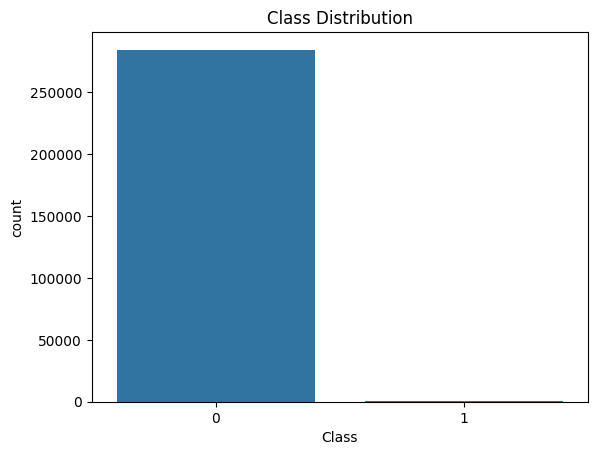

In [5]:
print(df['Class'].value_counts())
sns.countplot(x='Class', data=df)
plt.title("Class Distribution")
plt.show()


# Feature-Target Split

In [6]:
X = df.drop('Class', axis=1)
y = df['Class']


# Handle Class Imbalance with SMOTE

In [7]:
smote = SMOTE(random_state=42)
X_res, y_res = smote.fit_resample(X, y)


# Train-Test Split and Scaling

In [8]:
X_train, X_test, y_train, y_test = train_test_split(X_res, y_res, test_size=0.2, random_state=42)
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


# Define and Train Models


--- Logistic Regression ---
              precision    recall  f1-score   support

           0       0.97      0.99      0.98     56750
           1       0.99      0.97      0.98     56976

    accuracy                           0.98    113726
   macro avg       0.98      0.98      0.98    113726
weighted avg       0.98      0.98      0.98    113726

AUC: 0.9975

--- Random Forest ---
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56750
           1       1.00      1.00      1.00     56976

    accuracy                           1.00    113726
   macro avg       1.00      1.00      1.00    113726
weighted avg       1.00      1.00      1.00    113726

AUC: 1.0

--- Naive Bayes ---
              precision    recall  f1-score   support

           0       0.88      0.98      0.93     56750
           1       0.97      0.87      0.92     56976

    accuracy                           0.92    113726
   macro avg       0.93      0.92 

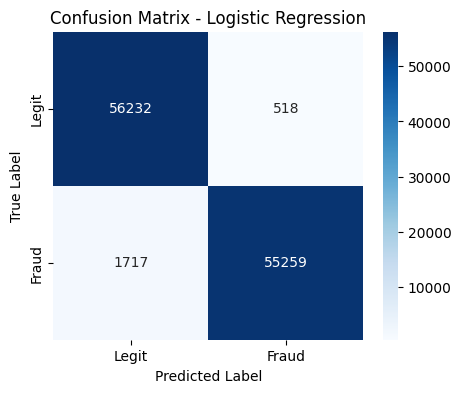

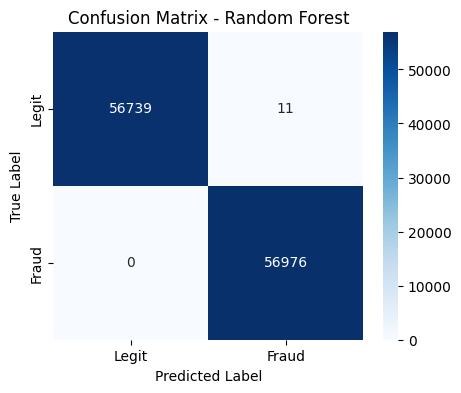

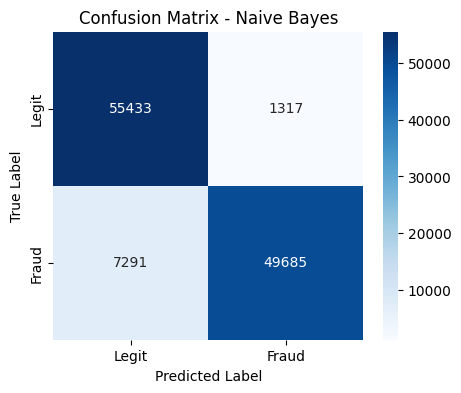

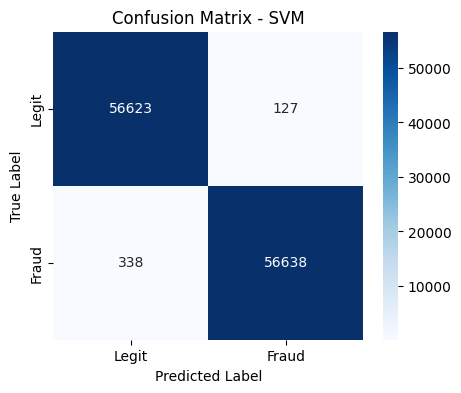

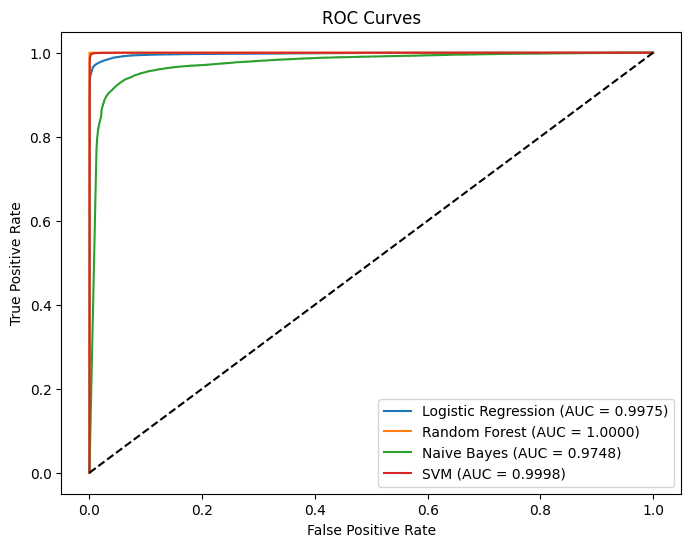

Best model saved: Random Forest


In [11]:
models = {
    "Logistic Regression": LogisticRegression(),
    "Random Forest": RandomForestClassifier(),
    "Naive Bayes": GaussianNB(),
    "SVM": SVC(probability=True)
}

results = []

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    y_prob = model.predict_proba(X_test)[:, 1]

    acc = np.round(np.mean(y_pred == y_test), 4)
    prec = np.round(classification_report(y_test, y_pred, output_dict=True)['1']['precision'], 4)
    rec = np.round(classification_report(y_test, y_pred, output_dict=True)['1']['recall'], 4)
    f1 = np.round(classification_report(y_test, y_pred, output_dict=True)['1']['f1-score'], 4)
    auc = np.round(roc_auc_score(y_test, y_prob), 4)

    results.append([name, acc, prec, rec, f1, auc])

    print(f"\n--- {name} ---")
    print(classification_report(y_test, y_pred))
    print("AUC:", auc)

results_df = pd.DataFrame(results, columns=["Model", "Accuracy", "Precision", "Recall", "F1-Score", "AUC"])
print(results_df)

# Plot confusion matrix
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
    plt.title(f"Confusion Matrix - {name}")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()

# ROC Curves

plt.figure(figsize=(8,6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()

# Select best module
best_model_name = results_df.sort_values(by="AUC", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

joblib.dump(best_model, "fraud_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print(f"Best model saved: {best_model_name}")

# Confusion Matrices

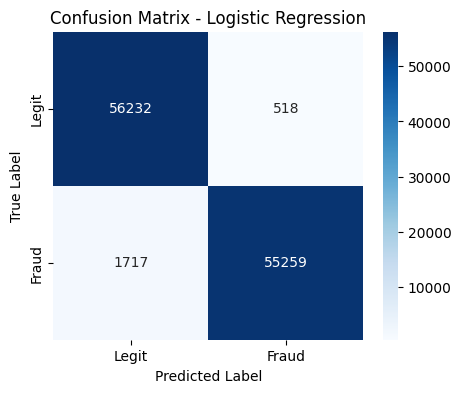

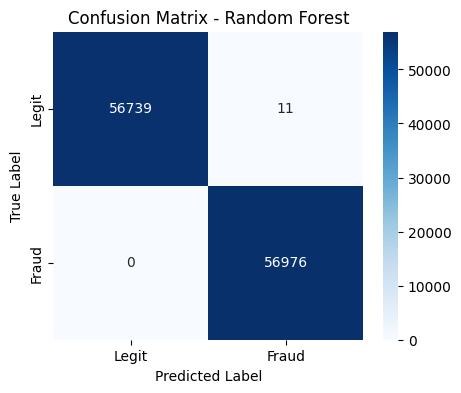

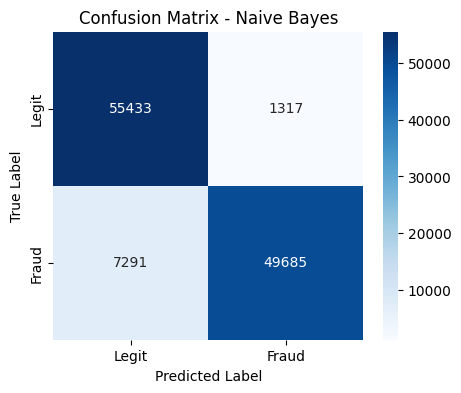

In [ ]:
for name, model in models.items():
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(5,4))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Legit", "Fraud"], yticklabels=["Legit", "Fraud"])
    plt.title(f"Confusion Matrix - {name}")
    plt.ylabel('True Label')
    plt.xlabel('Predicted Label')
    plt.show()


# ROC Curves

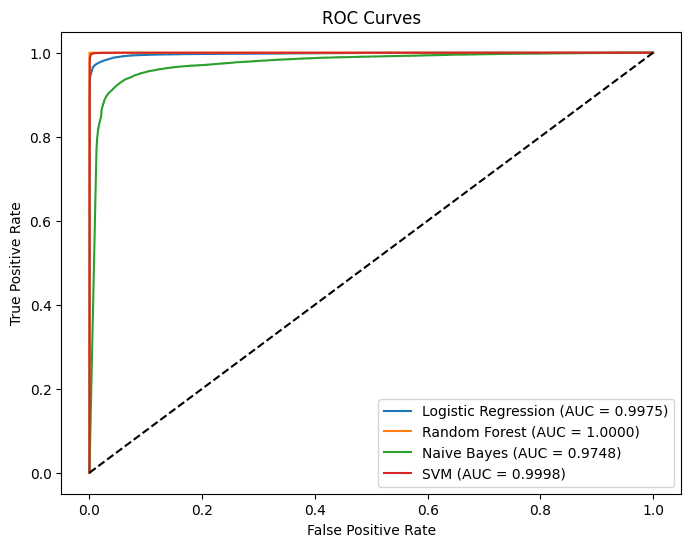

In [12]:
plt.figure(figsize=(8,6))
for name, model in models.items():
    y_prob = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    auc = roc_auc_score(y_test, y_prob)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {auc:.4f})")

plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()


# Save the Best Model

In [ ]:
best_model_name = results_df.sort_values(by="AUC", ascending=False).iloc[0]["Model"]
best_model = models[best_model_name]

joblib.dump(best_model, "fraud_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print(f"Best model saved: {best_model_name}")
